##FASE 1 PROYECTO AGRICULTURA DIGITAL (CAFÉ Y ARROZ)

- Jose David Libreros Alvarez
- Maria Paz Henao Bedoya

##**DATASET CAFÉ**

Para el desarrollo del proyecto de agricultura digital, es necesario conocer como se comportan las variables que afectan el cultivo del café, con las cuales se va a trabajar al momento de tomar datos desde los sensores. Se seleccionó para el cultivo del café la región del huila, por su alta importancia en la producción cafetera nacional. Las variables de temperatura, humedad relativa y radiación solar fueron obtenidas desde la plataforma NASA POWER, la cual permite consultar datos históricos diarios para una ubicación específica. En este caso, se trabajó con registros desde el 1 de diciembre de 2015 hasta el 12 de diciembre de 2024, con el fin de analizar el comportamiento temporal de las condiciones climáticas asociadas al cultivo.

<br>

Sin embargo, la variable pH del suelo no se encuentra disponible directamente en NASA POWER, debido a que esta plataforma está enfocada principalmente en variables meteorológicas y de radiación. Por esta razón, se complementó el dataset con registros de pH tomados del dataset Soil Climate Crop Dataset, recomendado en la guía del trabajo.

<br>

Es importante tener en cuenta esto ya que las variables climáticas cambian diariamente, mientras que el pH del suelo suele variar de forma más lenta en el tiempo. Debido a esto no fue necesario recoger información del día a día en la región del huila, sino los valores aproximados que tiene el pH en diversos suelos, lo que nos ayuda a generar datos más confiables y analizarlos desde los sensores seleccionados anteriormente.

<br>

Al recolectar la información necesaria de ambos dataset, se incluyeron manualmente en un documento de Excel separado por comas, para que al utilizar a futuro herramientas como Python los datos se puedan leer con mayor facilidad. A continuación se adjunta el link de los datos tomados de ambos dataset.

DATASET Variables Café: https://docs.google.com/spreadsheets/d/1ljknE1T1Dx7-93_KOvWwjbkUPKerl2wW/edit?usp=sharing&ouid=103419233822271347340&rtpof=true&sd=true



##**ANALISIS EDA (CAFÉ)**

El análisis exploratorio de datos (EDA) para el cultivo del café, nos permite comprender el comportamiento, la distribución y la relación entre las variables agroclimáticas que influyen en su crecimiento y productividad. A través de este análisis es posible encontrar patrones, tendencias y posibles anomalías en los datos, lo que nos facilitará una mejor interpretación de las condiciones del entorno y apoya la toma de decisiones en este sistema de agricultura digital.

<br>

En este caso el análisis se realizará utilizando Python, empleando los datos del dataset recolectados previamente. Mediante herramientas de análisis y visualización, se observaran las características principales del dataset, con el objetivo de obtener una comprensión clara del comportamiento de variables.


##**ESTRUCTURA DEL DATASET (CAFÉ)**

En primer lugar, se revisó la estructura del dataset, construido manualmente a partir de la recolección de datos se los dos dataset seleccionados. Al realizar esta recolección de datos se escogió un numero determinado de datos para cada una de las variables y se fijó en $3.300$ ya que es un numero representativo de los últimos años en la región del huila, ya que si se escogen más datos el análisis quedaría muy general y lo que se busca es conocer cómo se comportan cada una de las variables en los últimos años.

<br>

##**TIPOS DE DATOS (CAFÉ)**

Los datos se presentan como variables numericas, la temperatura, la humedad, la radiación y el pH del suelo. El dataset de la NASA arroja tambien información especifica sobre el año y el dia de ese año. Las unidades y los datos esperados para cada uno son las siguientes:


| Variable | Descripción | Unidad | Tipo | Rango esperado |
|----------|------------|--------|------|----------------|
| AÑO | Año de la medición | - | Discreta | 2015 – 2024 |
| DIA | Día del año | - | Discreta | 1 – 365 |
| TEMPERATURA | Temperatura del aire a 2 metros | °C | Continua | 15 – 30 |
| HUMEDAD RELATIVA| Humedad relativa a 2 metros | % | Continua | 60 – 95 |
| RADIACIÓN SOLAR | Radiación solar en superficie | $\frac{W}{m^2}$ | Continua | 200 – 800 |
| pH | pH del suelo | - | Continua | 5.0 – 6.5 |

Aqui debemos tener en cuenta que $MJ/m²/day$ = megajulios por metro cuadrado por día, es la cantidad de energia solar que recibe un metro cuadrado de superficie en un dia, siendo $MJ$ la unidad de energía.

##**MEDIDAS DE TENDECIA CENTRAL (CAFÉ)**

En este punto se realizará un análisis inicial del dataset. A través de este proceso se identifican posibles problemas con los datos, como valores faltantes o registros duplicados, los cuales pueden afectar la validez de análisis si no se tratan adecuadamente.

Además de esto se calculan las medidas estadísticas fundamentales que permiten describir las características de las variables, como la media, mediana y la moda que son las medidas de tendencia central, también se encuentran la desviación estándar, la varianza, rango e intervalo intercuartílico que nos muestran la dispersión de los datos.


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

# =========================
# 1. Subir archivo
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

print("Archivo cargado correctamente")
display(df.head())

# =========================
# 2. Seleccionar SOLO columnas necesarias
# =========================
# C = TEMPERATURA
# D = HUMEDAD RELATIVA
# E = RADIACIÓN SOLAR
# G = PH

df = df.iloc[:, [2, 3, 4, 6]]

# Renombrar columnas
df.columns = ["temperatura", "humedad", "radiacion", "ph"]

print("\nColumnas seleccionadas:")
print(df.columns)

# =========================
# 3. Arreglar columna pH correctamente
# =========================

# Convertir a string
df["ph"] = df["ph"].astype(str)

# Eliminar TODOS los puntos
df["ph"] = df["ph"].str.replace(".", "", regex=False)

# Convertir a número
df["ph"] = df["ph"].astype(float)

# Escalar correctamente (dividir por 1,000,000)
df["ph"] = df["ph"] / 1000000


# =========================
# 4. Datos faltantes
# =========================
nulos = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().sum() / len(df)) * 100
})

print("\nDATOS FALTANTES:")
display(nulos)

# =========================
# 5. Datos duplicados
# =========================
duplicados = df.duplicated().sum()

print("\nDATOS DUPLICADOS:", duplicados)

df = df.drop_duplicates()

# =========================
# 6. Medidas de tendencia central
# =========================
tendencia = pd.DataFrame({
    "Media": df.mean(),
    "Mediana": df.median(),
    "Moda": df.mode().iloc[0]
})

print("\nTENDENCIA CENTRAL:")
display(tendencia)

# =========================
# 7. Medidas de dispersión
# =========================
dispersion = pd.DataFrame({
    "Desviación estándar": df.std(),
    "Varianza": df.var(),
    "Mínimo": df.min(),
    "Máximo": df.max(),
    "Rango": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

print("\nDISPERSIÓN:")
display(dispersion)

# =========================
# 8. Resumen general
# =========================
print("\nRESUMEN ESTADÍSTICO:")
display(df.describe())

Saving DATASET CAFÉ.xlsx to DATASET CAFÉ (5).xlsx
Archivo cargado correctamente


,AÑO,DIA,TEMPERATURA,HUMEDAD RELATIVA,RADIACIÓN SOLAR,Unnamed: 5,Ph,Unnamed: 7,-BEGIN HEADER-
0,2015,335,15.48,86.87,3.18,NaN,5178290,NaN,NASA/POWER Source Native Resolution Daily Data
1,2015,336,16.08,85.71,8.88,NaN,4862699,NaN,Dates (month/day/year): 12/01/2015 through 12/...
2,2015,337,16.45,84.43,15.22,NaN,7691357,NaN,Location: latitude 1.8533 longitude -76.0452
3,2015,338,15.56,84.38,2.62,NaN,6482151,NaN,elevation from MERRA-2: Average for 0.5 x 0.62...
4,2015,339,16.30,77.39,8.02,NaN,6054078,NaN,The value for missing source data that cannot ...



Columnas seleccionadas:
Index(['temperatura', 'humedad', 'radiacion', 'ph'], dtype='object')

DATOS FALTANTES:


,Valores nulos,Porcentaje (%)
temperatura,0,0.0
humedad,0,0.0
radiacion,0,0.0
ph,0,0.0



DATOS DUPLICADOS: 0

TENDENCIA CENTRAL:


,Media,Mediana,Moda
temperatura,15.753312,15.810000,16.260000
humedad,86.138009,86.890000,87.440000
radiacion,6.753791,5.780000,2.570000
ph,6.492378,6.487111,8.088511



DISPERSIÓN:


,Desviación estándar,Varianza,Mínimo,Máximo,Rango,Q1,Q3,IQR
temperatura,1.093115,1.194899,11.63000,19.100000,7.470000,15.067500,16.480000,1.412500
humedad,4.096803,16.783795,66.98000,95.060000,28.080000,83.927500,89.000000,5.072500
radiacion,4.516504,20.398806,0.10000,28.300000,28.200000,3.390000,9.175000,5.785000
ph,1.153877,1.331432,4.50027,8.498928,3.998658,5.489834,7.509255,2.019421



RESUMEN ESTADÍSTICO:


,temperatura,humedad,radiacion,ph
count,3300.000000,3300.000000,3300.000000,3300.000000
mean,15.753312,86.138009,6.753791,6.492378
std,1.093115,4.096803,4.516504,1.153877
min,11.630000,66.980000,0.100000,4.500270
25%,15.067500,83.927500,3.390000,5.489834
50%,15.810000,86.890000,5.780000,6.487111
75%,16.480000,89.000000,9.175000,7.509255
max,19.100000,95.060000,28.300000,8.498928


##**INTERPRETACIÓN DE RESULTADOS (MEDIDA TENDENCIA CENTRAL CAFÉ)**

Con este análisis se pueden identificar comportamientos relevantes para cada una de las variables con las cuales se trabajará.

-	**Temperatura**: en esta variable para la región de Pitalito Huila, se presenta una media de aproximadamente **15.75°C**, con valores que están entre **11.63°C** y **19.10°C**. Esta variabilidad es relativamente baja, como lo indica la desviación estándar que es **1.09**, ósea que las temperaturas se mantienen estables, dentro de los rangos adecuados para el cultivo del café.

- **Humedad relativa**: se observa una media de **86.14%**, con un rango que va desde **66.98%** a **95.06%**. Estos valores reflejan un ambiente altamente húmedo, caracteristico de esta zona cafetera. Sin embargo, la dispersión es moderada, ya que tiene una desviación esyandar de **4.10** esto indica que pueden existir momentos de menor humedad que podrían generar estrés hídrico leve o, por el contrario, niveles muy altos que podrían favorecer la aparición de enfermedades.

- **Radiación solar**: Aquí la media se sitúa en **6.75 MJ/m²/día**, con valores que van desde **0.1** hasta **28.3**, esta variable presenta una desviación de **4.52** lo que indica una alta variabilidad en la cantidad de energía solar recibida, esto es importante ya que valores extremos pueden afectar tanto el crecimiento como la calidad del grano.

- **pH del suelo**: Presenta una media de **6.49**, con valores entre **4.50** y **8.49**. Aunque el promedio se encuentra dentro del rango adecuado para el cultivo de café, la amplitud del rango y la desviación estándar **(1.15)** indican la presencia de valores extremos, tanto ácidos como alcalinos, que podrían afectar la disponibilidad de nutrientes en el suelo. Esto sugiere la importancia de monitorear y controlar esta variable dentro del sistema IoT propuesto.

Estos datos son muy importantes ya que nos permiten conocer como es el comportamiento de las variables en la región donde se implemetará nuestro sistema de agricultura digital.

##**DISTRIBUCIÓN DE VARIABLES (CAFÉ)**

Aquí se estudia la distribución de las variables numéricas del dataset, con el objetivo de comprender como se comportan los datos y si presentan algunas irregularidades. Para esto se implementa un código en Python hecho con inteligencia artificial, que genera histogramas acompañados de curvas de densidad y gráficos de caja, los cuales permiten visualizar la forma de la distribución, e identificar comportamientos claves de las variables.  


Adicionalmente, el código incluye la aplicación de métodos estadísticos que permiten detectar de manera cuantitativa valores atípicos, estos valores serian los que se alejan significativamente del comportamiento general de los datos y pueden influir en el cultivo o en el resultado del análisis.  

Este proceso nos permitirá entonces ver de manera más profunda la calidad del dataset, permitiendo ver algunos patrones relevantes y posibles inconsistencias antes de continuar utilizándolo para las siguientes fases del proyecto. Además, en nuestro contexto de agricultura digital y el sistema IoT agrícola, conocer la distribución de las variables es clave para usar los umbrales definidos en la fase 0 del proyecto y generar alertas, garantizando que los datos utilizados en la simulación si sean coherentes con condiciones reales de nuestro cultivo de café.



Saving DATASET CAFÉ.xlsx to DATASET CAFÉ (8).xlsx


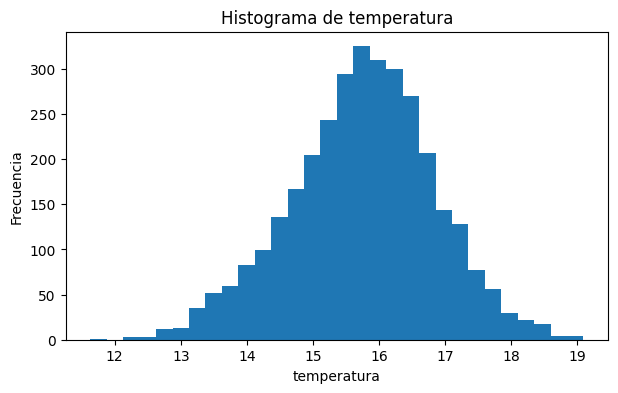

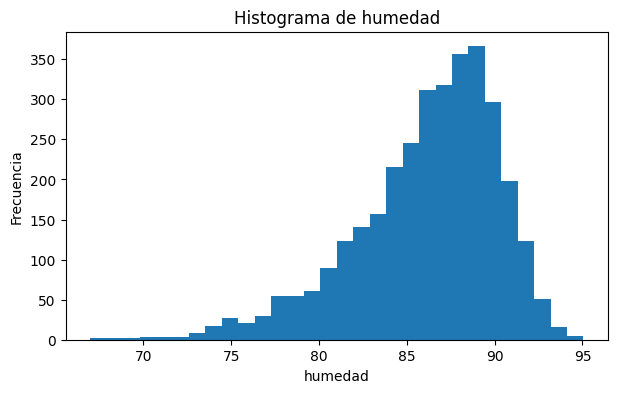

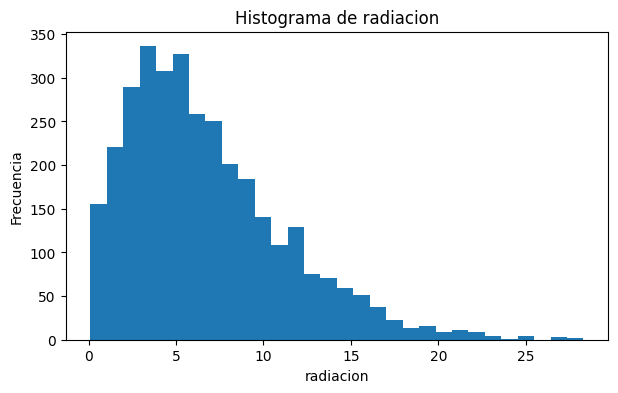

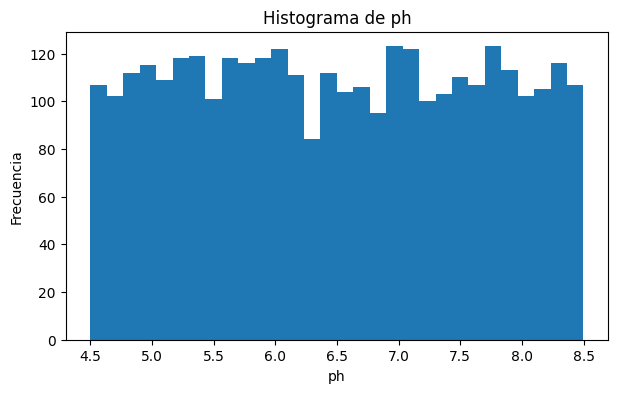

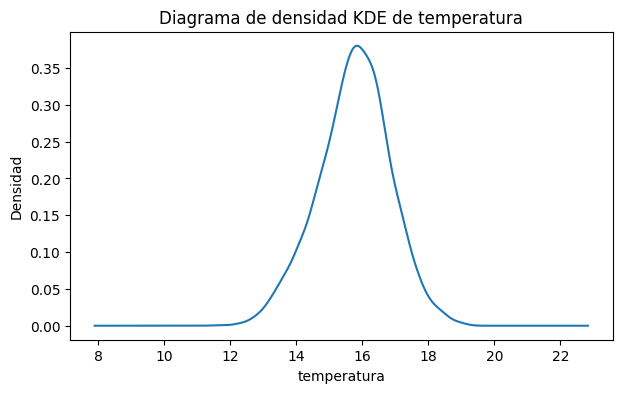

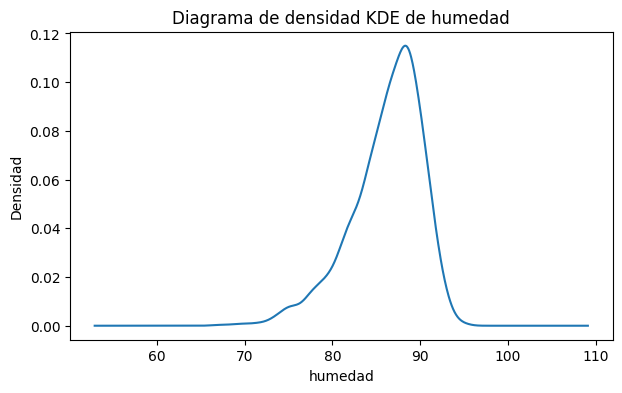

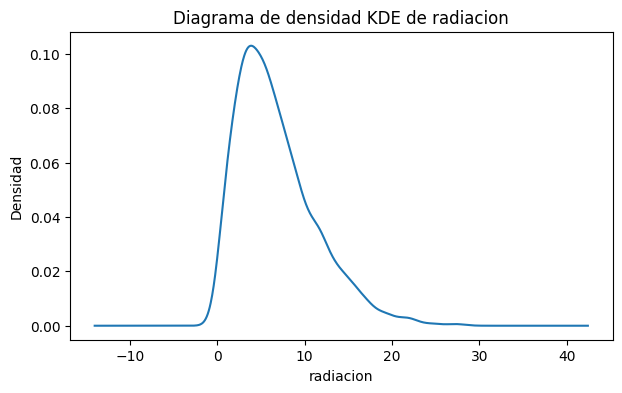

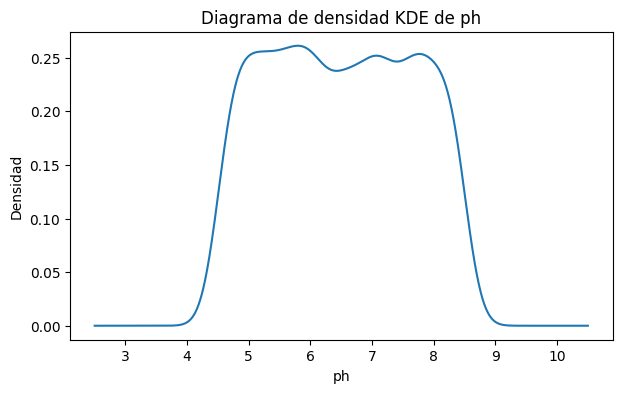

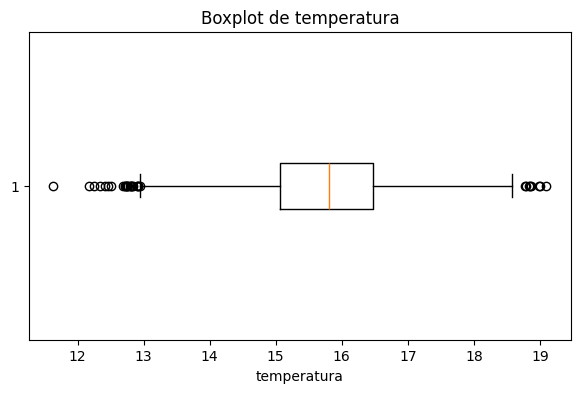

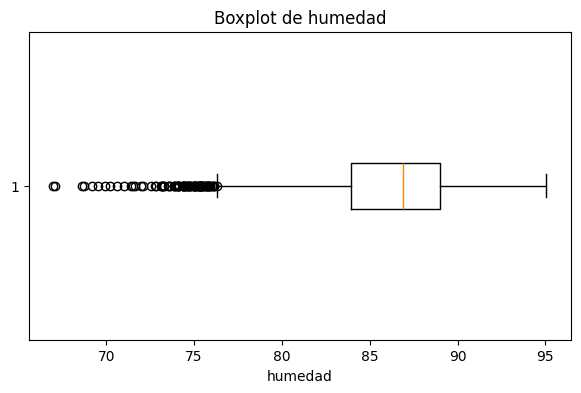

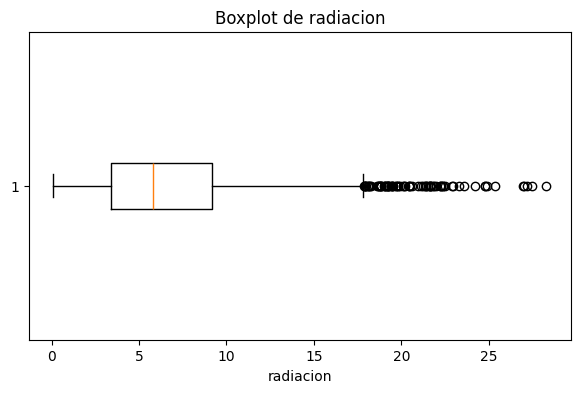

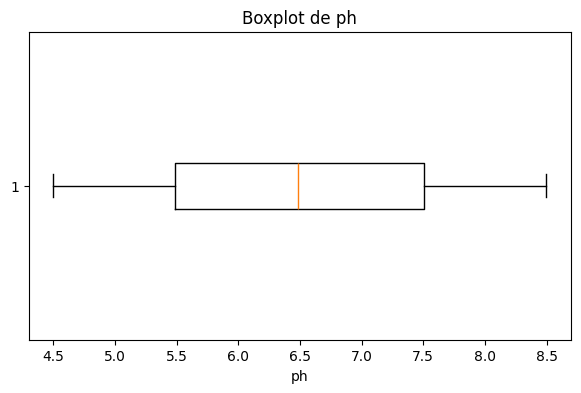

Valores atípicos detectados por método IQR:


,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
temperatura,15.067500,16.480000,1.412500,12.948750,18.598750,31.0,0.939394
humedad,83.927500,89.000000,5.072500,76.318750,96.608750,89.0,2.696970
radiacion,3.390000,9.175000,5.785000,-5.287500,17.852500,77.0,2.333333
ph,5.489834,7.509255,2.019421,2.460702,10.538387,0.0,0.000000


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Subir archivo
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)


# =========================
# 2. Seleccionar columnas necesarias
# C = temperatura, D = humedad, E = radiación, G = pH
# =========================
df = df.iloc[:, [2, 3, 4, 6]]
df.columns = ["temperatura", "humedad", "radiacion", "ph"]

# =========================
# 3. Corregir pH
# =========================
df["ph"] = df["ph"].astype(str)
df["ph"] = df["ph"].str.replace(".", "", regex=False)
df["ph"] = df["ph"].astype(float)
df["ph"] = df["ph"] / 1000000

# =========================
# 4. Asegurar variables numéricas
# =========================
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

# =========================
# 5. Histogramas
# =========================
for col in df.columns:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# =========================
# 6. Diagramas de densidad KDE
# =========================
for col in df.columns:
    plt.figure(figsize=(7,4))
    df[col].plot(kind="kde")
    plt.title(f"Diagrama de densidad KDE de {col}")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.show()

# =========================
# 7. Boxplots
# =========================
for col in df.columns:
    plt.figure(figsize=(7,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

# =========================
# 8. Detección de valores atípicos con IQR
# =========================
outliers_iqr = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    outliers_iqr[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": len(outliers),
        "Porcentaje de outliers": (len(outliers) / len(df)) * 100
    }

outliers_iqr_df = pd.DataFrame(outliers_iqr).T

print("Valores atípicos detectados por método IQR:")
display(outliers_iqr_df)

# =========================
# 9. Detección de valores atípicos con Z-score
# =========================
outliers_z = {}

for col in df.columns:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = df[np.abs(z_scores) > 3]

    outliers_z[col] = {
        "Cantidad de outliers": len(outliers),
        "Porcentaje de outliers": (len(outliers) / len(df)) * 100
    }

outliers_z_df = pd.DataFrame(outliers_z).T



##**INTERPRETACIÓN RESULTADOS GRAFICAS (CAFÉ)**

A partir de los histogramas y los diagramas obtenidos, se pudieron identificar características clave en la distribución de las variables:


-	**Temperatura:** se observa una distribución aproximadamente simétrica con forma de campana, lo que indica un comportamiento cercano a una distribución normal. El grafico se ajusta bien a lo encontrado anteriormente de la media y la poca variabilidad de la variable en el lugar seleccionado.

-	**Humedad relativa:** aquí la distribución nos presenta una ligera asimetría hacia la izquierda, un sesgo negativo, concentrando la mayoría de los valores entre un 80% y 90%, esto indica que el ambiente es mayormente húmedo, condición que favorece el cultivo del café. Sin embargo, la cola hacia valores más bajos sugiere la presencia ocasional de condiciones menos húmedas que podrían generar estrés en el cultivo.

-	**Radiación solar:** La mayoría de los valores se concentran en niveles bajos a moderados, mientras que existen pocos valores altos que generan una cola extendida. Este comportamiento es típico en variables climáticas, donde la radiación puede presentar picos en ciertos días. La KDE confirma esta asimetría, indicando alta variabilidad en la energía solar recibida.

-	**pH:** esta variable de pH presenta una distribución relativamente uniforme dentro del rango analizado en el punto anterior. La curva KDE muestra una forma más plana en comparación con otras variables, esto es debido a la integración del otro dataset en el original de la nasa. Aunque el promedio se mantiene dentro del rango adecuado para el cultivo de café, la amplitud del rango indica la presencia de valores potencialmente no óptimos que podrían afectar la disponibilidad de nutrientes.

##INTERPRETACIÓN DE VALORES ATÍPICOS (CAFÉ)

Con base en los resultados de los diagramas de caja y el método de rango intercuartílico, se lograron identificar los valores atípicos presentes en las variables:

-	**Temperatura:** Se identificaron 31 valores atípicos, lo que representa aproximadamente el 0.94% del total de registros. Estos valores se encuentran principalmente en los extremos inferior y superior de la distribución, fuera del rango establecido entre 12.95°C y 18.60°C. No obstante, debido a su bajo porcentaje y a que pueden corresponder a variaciones reales del clima, no se consideran críticos para el análisis.

-	**Humedad relativa:** Aquí se detectaron 89 valores atípicos lo cual equivale al 2.70% de los datos, esto sugiere que en ocasiones hay presencia de condiciones con menor humedad, que, aunque no son muy frecuentes pueden generar un estrés hídrico en el cultivo, con este proyecto, aquí es donde se generarían las alertas necesarias.

-	**Radiación solar:** En cuanto a la radiación solar se encontraron 77 valores atípicos, lo cual representa un 2.33% del total de datos en el dataset. Estos valores se encuentran principalmente por encima del limite superior, este comportamiento es esperable ya que los extremos pueden ocurrir debido a condiciones atmosféricas específicas.

- **pH:** Por otro lado, la variable pH del suelo no presenta valores atípicos según el método IQR, lo cual se refleja en un 0% de outliers, esto debido a lo que se explicó anteriormente de la poca variabilidad de este indicador.

En general, el bajo porcentaje de valores atípicos en todas las variables indica una buena calidad del dataset. Además, dado que estos valores pueden representar condiciones reales del entorno, no se consideran necesarios de eliminar, ya que aportan información relevante sobre la variabilidad del sistema agroclimático, y el objetivo es que cuando se presenten estos valores atipicos por fuera de los rangos esperados se puedan generar las alertas necesarias.

##PATRONES Y RELACIONES ENTRE LAS VARIABLES (CAFÉ)

Con el objetivo de analizar e identificar posibles interacciones entre las variables agroclimáticas, en esta parte también se analizaron la relación que existe entre cada una de las variables. Este análisis nos deja comprender como las condiciones ambientales pueden influir de manera conjunta el comportamiento del cultivo del café.  

<br>
Se observa una relación inversa moderada entre la temperatura y la humedad, donde aumentos en la temperatura tienden a provocar o a asociarse con disminuciones en la humedad relativa, esto es lógico ya que las altas temperaturas favorecen la evaporación y reducen la humedad del ambiente.
Por otro lado, la radiación solar muestra una relación positiva con la temperatura, ósea a mayor nivel de radiación mayor es la temperatura del entorno, esto también es lógico ya que la radiación solar es una de las principales fuentes de energía térmica en los cultivos, en nuestro caso del café.

<br>

La relación entre radiación solar y la humedad relativa entonces, es inversa ya que los niveles altos de radiación suelen coincidir con una baja humedad, Esto se debe a que una mayor radiación incrementa la evapotranspiración, reduciendo la cantidad de humedad disponible en el aire.  

<br>

El pH no presenta relaciones con las variables climáticas, ya que es una variable que depende principalmente de las características del suelo y no de cambios diarios en las condiciones atmosféricas.


#DATASET ARROZ
Para el desarrollo del proyecto de agricultura digital, es necesario conocer como se comportan las variables que afectan el cultivo del arrOz, con las cuales se va a trabajar al momento de tomar datos desde los sensores. Se seleccionó para el cultivo del arróz la región de Casanare, ya que es una de las regiones mas productoras del pais alcanzando 1.119.646 de toneladas para el  segundo semestre del año 2024 aportando entre el 40% y el 45% del total nacional de arroz. Las variables de temperatura, humedad volumetrica del suelo y radiación solar fueron obtenidas desde la plataforma NASA POWER DATASET, la cual permite consultar datos históricos diarios para una ubicación específica. En este caso, se trabajó con registros desde el 20 de diciembre de 2015 hasta el 31 de diciembre de 2024, un lapso aproximado de 10 años, con el fin de analizar el comportamiento temporal de las condiciones climáticas asociadas al cultivo.

Sin embargo, al igual que en el caso del café, la variable pH del suelo no se encuentró disponible directamente en NASA POWER DATASET, debido a que esta plataforma está enfocada principalmente en variables meteorológicas y de radiación. Por esta razón, se complementó el registro de variables con datos de pH tomados desde dataset Soil Climate Crop Dataset, recomendado en la guía del trabajo

La recolección de datos con variación por días se aplicó únicamente a las variables de temperatura, humedad relativa y radiación solar sobre la planta. Esto se debe a que el pH cambia de forma mucho más lenta a lo largo del tiempo.

Por esta razón, los datos de pH en el dataset se recopilaron teniendo en cuenta los distintos tipos de suelo, lo que requiere un análisis un poco diferente al de las demás variables. En este caso, el enfoque se centra en el tipo de suelo y en cómo este influye en el pH, evidenciando su papel clave para mantener un rango óptimo necesario para el cultivo de arroz
<br><br>
[Dataset Cultivo de Arroz](https://drive.google.com/file/d/1q3V0KKcdV-Khjnj0-SyJ092RG-4H-ZXg/view?usp=sharing)


#**ANALISIS EDA**

El análisis exploratorio de datos (EDA) se realiza con el objetivo de entender mejor la información antes de sacar conclusiones más profundas. En el caso del cultivo de arroz, este proceso permite analizar cómo se comportan variables como la temperatura, la humedad volumétrica, la radiación solar y el pH. A través del EDA se pueden identificar valores promedio, la variación de estas variables y posibles datos atípicos o errores en el registro. Además, ayuda a encontrar relaciones entre ellas, como la influencia de la temperatura o la radiación en las condiciones del cultivo. También permite entender cómo se distribuyen los datos y reconocer que algunas variables, como el pH, presentan cambios más lentos y dependen en mayor medida del tipo de suelo. Todo esto facilita tomar mejores decisiones para el análisis posterior y comprender qué factores son más relevantes para el desarrollo adecuado del cultivo de arroz.
<br></br>

##ESTRUCTURA DEL DATASET
Numero de Variables: 4 (Columnas) <br>
Numero de registros: 3300 por variable (Filas)
<br></br>
##TIPOS DE DATOS <br>

1.   **pH**: numérica continua <br>
2.   **Temperatura**: numérica continua <br>
3.  **Humedad volumetrica del suelo**: numérica continua
4.   **Radiacion solar**: numérica continua
5. **Años/Dias**:
<br>
Definicion, unidades y rangos validos para cada variable
Los rangos validos incluyen los rangos minimos y maximos optimos asi como los rangos de umbral minimo y maximo
<br></br>

###**Temperatura**
Magnitud fisica que representa el estado térmico de un cuerpo o ambiente en un momento dado.


A traves de su medicion en el tiempo por medio de sensores de temperatura se puede obtener la variacion de esta. Permitiendo realizar los analisis de los datos y su monitoreo para con el cultivo.

Unidad:  $ºC$ (Grados celsius)

Los rangos validos de temperatura para un cultivo de arroz estan entre los $35ºC$ (maxima) y los $15ºC$ (minima). Este rango se especifica, teniendo en cuenta las fases de desarrollo de la planta, los horarios diurnos y nocturnos. Cabe resaltar que cada fase de desarrollo de la planta requiere temperaturas y momentos del dia distintos.
<br></br>

###**Humedad volumetrica del suelo**
El contenido volumetrico de agua $\theta$ se define como la relación entre el volumen de agua $V_{a}$ presente en una muestra de suelo y el volumen total de dicha muestra $V_{t}$ el cual incluye los poros ocupados por aire y agua, y la fracción sólida
se enfoca en el espacio físico que ocupa el agua
$\theta = \frac{V_{a}}{V_{t}}$

Unidad:
*   Porcentual: $\theta * 100$ = %
*   $cm3/cm3$ o $m3/m3$

Los rangos validos de humedad volumetrica del suelo para un cultivo de arroz estan entre 50% y 90%.
<br></br>

###**Radiacion solar**
Es la potencia de la radiación solar por unidad de área que incide sobre la superficie del cultivo. Incluye la radiación directa del sol y la difusa del cielo

Unidad:
* potencia instantanea h/m/s: $Wm^2$ o $kW/m^2$
* Energia total acumulada en el dia (promedio del día completo): $MJ/m²/día$

$\text{Valor en } W/m^2 = \frac{\text{Dato en } MJ \times 1,000,000}{86,400 \text{ segundos (un día)}}$

Los rangos validos de irradiancia solar para un cultivo de arroz estan entre $150W/m^2$ y $1200W/m^2$. <br>Si hablamos de rango aceptable de energia en el dia (24h) $12 MJ/m²/día > R_s > 30 MJ/m²/día$
<br></br>

### **PH (Potencia de hidrogeno del suelo)**
Indica qué tan ácida o alcalina (básica) es una sustancia o el suelo. En el caso del arroz, el pH determina qué tan fácil le resulta a la raíz absorber los nutrientes del suelo.

Escala o rango: 0 a 14

Los rangos validos de pH en cultivos de arroz son $5.5pH$ a $8.4pH$
Un pH alto detiene su crecimiento debido a las deficiencias graves de Zinc y un pH bajo puede provocar toxicidad por Aluminio o Hierro si no se controla.
<br></br>

##Tabla con las especificaciones resumidas
| Variable | Descripción | Unidad | Tipo | Rango esperado |
|----------|------------|--------|------|----------------|
| AÑO | Año de la medición | - | Discreta | 2015 – 2024 |
| DIA | Día del año | - | Discreta | 1 – 365 |
| TEMPERATURA | Temperatura del aire a 2 metros | °C | Continua | 15 – 35 |
| HUMEDAD VOLUMÉTRICA | Humedad del suelo en la zona radicular (desde la superficie hasta 100 cm de profundidad) | % | Continua | 50 – 85 |
| RADIACIÓN SOLAR | Irradiancia descendente de onda corta en toda la superficie del cielo<br> | MJ/m²/day | Continua | 12 – 30 |
| pH | pH del suelo | - | Continua | 5.5 – 8.4 |

##**MEDIDAS DE TENDENCIA CENTRAL**

In [1]:
from google.colab import files
import pandas as pd
import io

# Subir archivo
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Leer CSV o Excel automáticamente
if filename.endswith(".csv"):
    # Read CSV from the uploaded bytes content
    # Try different encodings if 'utf-8' fails, 'latin1' is a common fallback
    try:
        file_content = uploaded[filename].decode('utf-8')
    except UnicodeDecodeError:
        file_content = uploaded[filename].decode('latin1') # More permissive encoding

    # Use io.StringIO to read the string content as a file.
    # Use 'sep=;' and 'decimal=,' as indicated by the user's data structure.
    df = pd.read_csv(io.StringIO(file_content), sep=';', decimal=',')
else:
    # Read Excel directly from uploaded bytes content
    df = pd.read_excel(io.BytesIO(uploaded[filename]))

print("Vista inicial:")
print(df.head())


# =========================
# Selección de columnas (por nombre, no por posición)
# =========================

# Normalizar nombres
df.columns = df.columns.str.lower().str.strip()

# Posibles nombres (por si cambian un poco)
col_temp = [c for c in df.columns if "temp" in c][0]
col_hum = [c for c in df.columns if "hum" in c][0]
col_rad = [c for c in df.columns if "rad" in c][0]
col_ph = [c for c in df.columns if "ph" in c][0]

# Select columns in the desired final order
df = df[[col_hum, col_temp, col_rad, col_ph]]
df.columns = [ "Humedad Volumetrica del Suelo", "Temperatura","Promedio Radiacion Solar", "pH"]

print("\nColumnas usadas:")
print(df.columns)


# =========================
# Limpieza de pH (solo si hace falta)
# =========================

# Intentar convertir directo
df["pH"] = pd.to_numeric(df["pH"], errors="coerce")


if df["pH"].max() > 14 and df["pH"].dropna().shape[0] > 0:
    pass # Removed specific pH cleaning block

# =========================
# Nulos
# =========================
print("\nNulos:")
print(df.isnull().sum())


# =========================
# Duplicados
# =========================
print("\nDuplicados:", df.duplicated().sum())
df = df.drop_duplicates()


# =========================
# Estadísticas básicas
# =========================
print("\nResumen:")
print(df.describe())


# =========================
# Medidas manuales (más simple)
# =========================
print("\nMedia:")
print(df.mean())

print("\nMediana:")
print(df.median())

print("\nDesviación estándar:")
print(df.std())

Saving DATASET_ARROZ1.csv to DATASET_ARROZ1.csv
Vista inicial:
     YEAR    DOY  Humedad Volumetrica del Suelo  Temperatura  \
0  2015.0  354.0                           0.70        27.08   
1  2015.0  355.0                           0.69        26.71   
2  2015.0  356.0                           0.69        26.82   
3  2015.0  357.0                           0.68        26.40   
4  2015.0  358.0                           0.67        26.78   

   Promedio Radiacion Solar    pH  
0                     20.77  4.83  
1                     21.78  7.20  
2                     21.64  6.83  
3                     21.81  5.67  
4                     21.64  7.62  

Columnas usadas:
Index(['Humedad Volumetrica del Suelo', 'Temperatura',
       'Promedio Radiacion Solar', 'pH'],
      dtype='object')

Nulos:
Humedad Volumetrica del Suelo    353
Temperatura                      353
Promedio Radiacion Solar         353
pH                               353
dtype: int64

Duplicados: 352

Resumen:
   

Las variables de temperatura y humedad son estables y adecuadas para el cultivo de arroz.
La radiación solar presenta variabilidad, lo que puede influir en el rendimiento en ciertos días.
El pH promedio es adecuado, pero su alta desviacion con un $1.16$ indica posibles zonas o momentos con condiciones menos favorables ya sea o muy alcalinos y muy acidos, presentando problemas las etapas de floracion y desarrollo del grano, debido a la falta de nutrientes o el ato indice de toxicidad.

##HISTOGRAMA PARA CADA VARIABLE

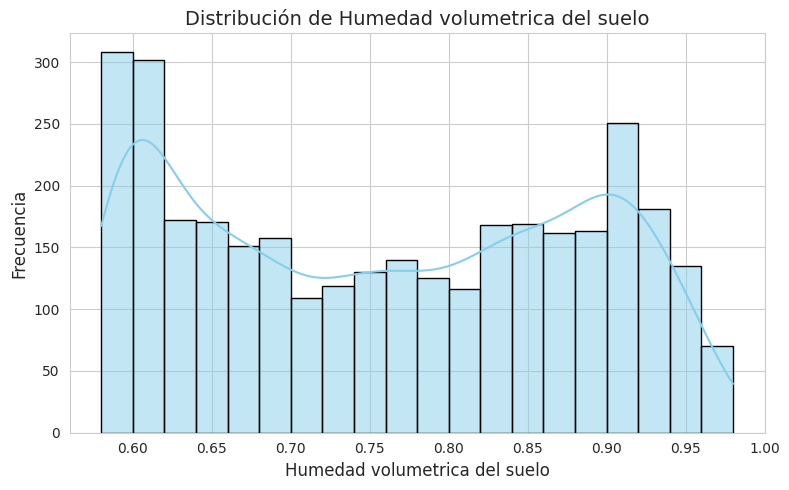

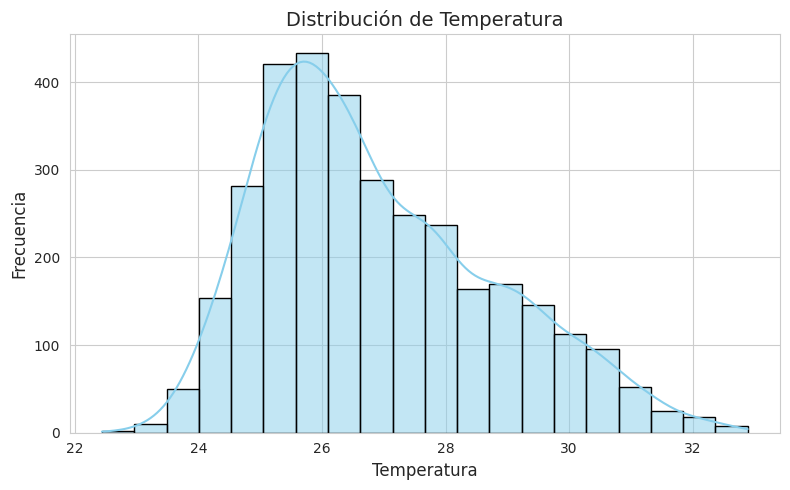

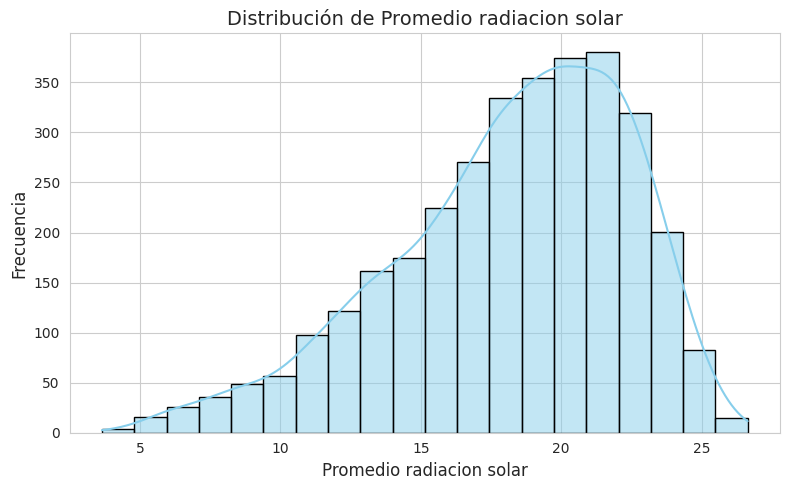

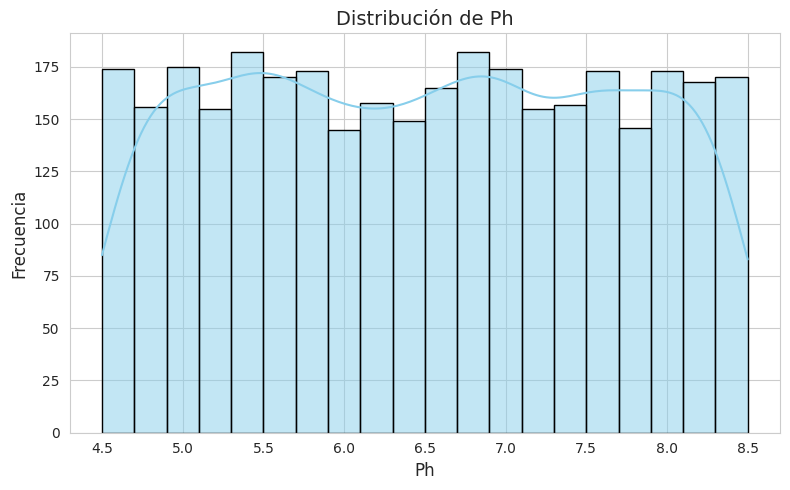

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files
import io

# Lista de variables
columnas = [ "Humedad Volumetrica del Suelo", "Temperatura","Promedio Radiacion Solar", "pH"]

# Verificar si df existe, si no, cargarlo
if 'df' not in locals() and 'df' not in globals():
    print("El DataFrame 'df' no está definido. Cargando el archivo nuevamente...")
    # Subir archivo
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # Leer CSV o Excel automáticamente
    if filename.endswith(".csv"):
        try:
            file_content = uploaded[filename].decode('utf-8')
        except UnicodeDecodeError:
            file_content = uploaded[filename].decode('latin1')
        df = pd.read_csv(io.StringIO(file_content), sep=';', decimal=',')
    else:
        df = pd.read_excel(io.BytesIO(uploaded[filename]))

    # Normalizar nombres de columnas y seleccionar
    df.columns = df.columns.str.lower().str.strip()
    col_temp = [c for c in df.columns if "temp" in c][0]
    col_hum = [c for c in df.columns if "hum" in c][0]
    col_rad = [c for c in df.columns if "rad" in c][0]
    col_ph = [c for c in df.columns if "ph" in c][0]
    # Select columns in the desired final order
    df = df[[col_hum, col_temp, col_rad, col_ph]]
    df.columns = ["Humedad Volumetrica del Suelo", "Temperatura","Promedio Radiacion Solar", "pH"]

# Aplicar un estilo más estético de Seaborn
sns.set_style("whitegrid")

for col in columnas:
    plt.figure(figsize=(8, 5)) # Aumentar el tamaño de la figura
    sns.histplot(df[col].dropna(), bins=20, kde=True, color='skyblue', edgecolor='black') # Usar seaborn.histplot para mejor estética

    plt.title(f"Distribución de {col.capitalize()}", fontsize=14) # Capitalizar el título y ajustar fuente
    plt.xlabel(col.capitalize(), fontsize=12) # Capitalizar etiquetas de eje y ajustar fuente
    plt.ylabel("Frecuencia", fontsize=12)

    plt.tight_layout() # Ajustar el diseño para evitar solapamientos
    plt.show()
    print("\n\n") # Añadir saltos de párrafo entre gráficas

##BOXPLOT PARA CADA VARIABLE


Tabla IQR:


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,Humedad Volumetrica del Suelo,0.6400,0.8700,0.2300,0.29500,1.21500,0,0.000000
1,Temperatura,25.4875,28.0800,2.5925,21.59875,31.96875,21,0.636364
2,Promedio Radiacion Solar,15.6100,21.4525,5.8425,6.84625,30.21625,40,1.212121
3,pH,5.4800,7.5000,2.0200,2.45000,10.53000,0,0.000000


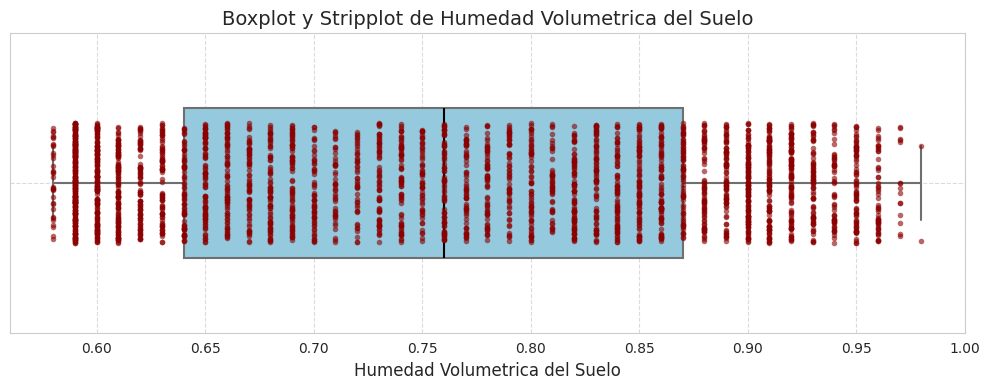

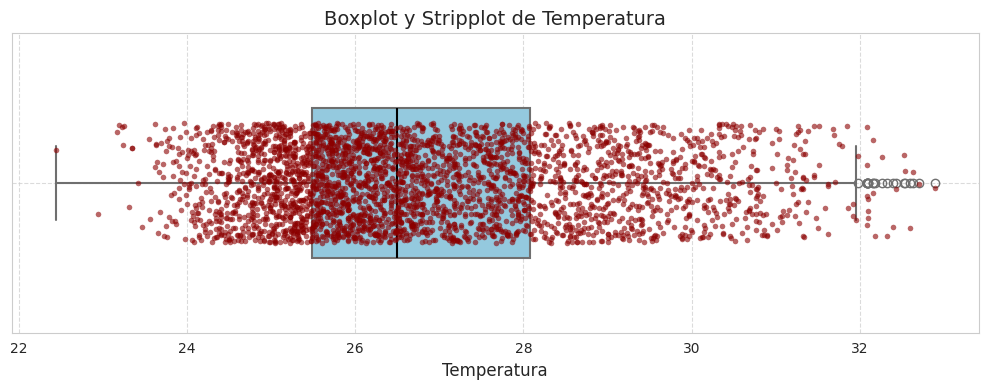

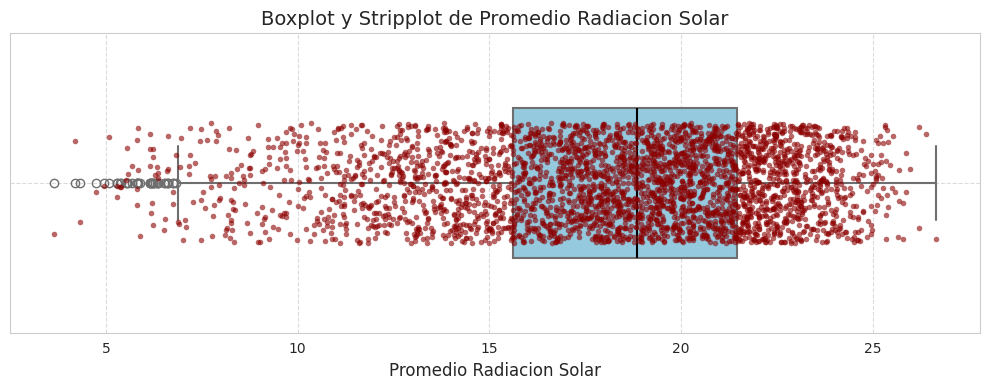

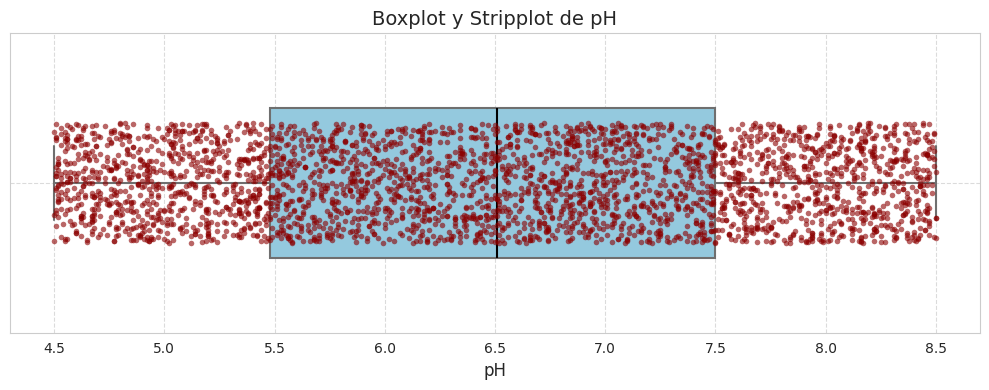

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columnas = [ "Humedad Volumetrica del Suelo", "Temperatura","Promedio Radiacion Solar", "pH"]

resultados = []

for col in columnas:
    datos = df[col].dropna()

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]

    cantidad_outliers = len(outliers)
    porcentaje_outliers = (cantidad_outliers / len(datos)) * 100

    resultados.append([
        col, Q1, Q3, IQR,
        limite_inf, limite_sup,
        cantidad_outliers,
        porcentaje_outliers
    ])

# Crear tabla
tabla_iqr = pd.DataFrame(resultados, columns=[
    "Variable", "Q1", "Q3", "IQR",
    "Límite inferior", "Límite superior",
    "Cantidad de outliers", "Porcentaje de outliers"
])

print("\nTabla IQR:")
display(tabla_iqr)


# =========================
# Boxplots combinados con Stripplots
# =========================
sns.set_style("whitegrid") # Aplicar un estilo de Seaborn

for col in columnas:
    plt.figure(figsize=(10, 4)) # Aumentar el tamaño de la figura

    # Crear el boxplot horizontal
    sns.boxplot(x=df[col].dropna(), orient='h', color='skyblue', width=0.5, linewidth=1.5, medianprops={'color':'black'})

    # Añadir el stripplot para ver los puntos individuales
    sns.stripplot(x=df[col].dropna(), orient='h', color='darkred', size=4, jitter=0.2, alpha=0.6)

    plt.title(f"Boxplot y Stripplot de {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("") # Eliminar etiqueta del eje Y ya que es un solo grupo
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("\n\n") # Añadir saltos de párrafo entre gráficas

##**INTERPRETACIÓN RESULTADOS GRAFICAS (ARROZ)**

A partir de los diagramas analiticos (histogramas y los boxplots) obtenidos, se pudieron identificar características clave en la distribución de las variables en el lapso de tiempo expedificado en el dataset

**Temperatura:** Se observa una distribucion mas intensificada en 26ºC. Esta valor si revisamos el rango valido para temperatura, cumple estando dentro de el, sin embargo es un valor que está al limite del rango optimo, lo que nos indica que la temperatura en el casanare en la liena de tiempo del 2016 al 2024 estuvo relativamente baja. De todos modos, es un valor razonnable que cumple con las espectativas requeridas para el valor de temperatura. Mediante la grafica con la estimación de densidad (KDE) podemos visualizar que hay varios datos fuera del rango intensificado los vuales podemos representar comoun pequeño sesgo hacia la derecha.

**Humedad volumétrica del suelo:**
Se observa que la distribución no es uniforme ni sigue una forma normal, sino que presenta un comportamiento bimodal, evidenciado por dos concentraciones de datos (dos picos) claramente diferenciadas. El primer pico se ubica aproximadamente alrededor del 60%, mientras que el segundo se encuentra cercano al 90%, lo que indica que el suelo tiende a presentarse en dos estados de humedad distintos: uno moderado y otro alto.

Este patrón puede estar asociado a variaciones en las condiciones del entorno, como periodos de riego o acumulación de agua en el suelo.
El boxplot evidencia una distribución amplia de la humedad volumétrica del suelo, con una mediana cercana a 0.75 y una concentración significativa de valores en rangos altos, lo que sugiere al igual que en el histograma, posibles condiciones de saturación en determinados periodos

Al contrastar estos resultados con los rangos óptimos para el cultivo de arroz (entre 50% y 80%), se observa que una parte significativa de los datos (alrededor del primer pico) se encuentra dentro del rango adecuado. Sin embargo, el segundo pico (≈90%) supera el límite óptimo, lo que podría indicar condiciones de exceso de humedad o saturación del suelo en la zona de casanare entre 2015 y 2024.

**Radiación solar:**
Se observa una distribución con mayor concentración de valores alrededor de 21 MJ/m²/día, lo que indica que este es el rango más frecuente en los datos. Al comparar con los rangos óptimos (12 a 30 MJ/m²/día), se puede afirmar que la radiación solar en el área de Casanare se encuentra dentro del rango adecuado para el cultivo de arroz.

La estimación de densidad (KDE), que suaviza el histograma para mostrar la forma general de la distribución, evidencia un ligero sesgo hacia la izquierda (cola más extendida hacia valores bajos). Esto sugiere que existen algunos valores más dispersos por debajo del promedio, aunque la mayoría de los datos se concentra en valores medios-altos.

**pH:** En el histograma de la distribución de la variable pH se observa que los datos presentan una distribución relativamente uniforme dentro del rango aproximado de 4.5 a 8.5. No se evidencia una concentración marcada de valores en un intervalo específico, lo que sugiere que el pH se distribuye de manera bastante homogénea en el conjunto de datos. Además, no se encuentran picos pronunciados ni sesgos evidentes hacia valores ácidos o alcalinos, indicando una variabilidad moderada y una ausencia de valores atípicos significativos. Dado que el database empleado presenta datos de varios tipos de suelos, nos indica que estos suelos tienen la capacidad y caracteristicas que permiten un buen desarrollo para ek cultivo de arroz.

##INTERPRETACIÓN DE VALORES ATÍPICOS (ARROZ)

En las variables de temperatura, radiación solar y humedad volumétrica del suelo se observa la presencia de una pequeña cantidad de valores atípicos.
En el caso de la temperatura y la radiación solar, las distribuciones presentan una forma aproximadamente acampanada, con ligeros sesgos, lo que sugiere un comportamiento cercano a una distribución normal. Esta tendencia también se ve reflejada en los boxplots, donde la mayoría de los datos se concentran dentro de los rangos intercuartílicos, con pocos valores extremos.

Por otro lado, la humedad volumétrica del suelo no sigue este patrón, ya que presenta un comportamiento bimodal, evidenciado por dos zonas de alta concentración de datos en diferentes intervalos. Esto indica la posible existencia de dos condiciones distintas del suelo (por ejemplo, niveles moderados y altos de humedad).

Respecto al pH, no se observa un valor predominante ni presencia significativa de valores atípicos, lo que sugiere una distribución homogénea dentro del rango analizado. Esto indica que el pH del suelo se mantiene relativamente estable, sin variaciones bruscas ni concentraciones extremas

##PATRONES Y RELACIONES ENTRE LAS VARIABLES (ARROZ)

En general, las variables analizadas muestran un comportamiento acorde con las condiciones necesarias para el cultivo de arroz en la región de Casanare. La temperatura y la radiación solar se mantienen dentro de rangos adecuados y presentan distribuciones relativamente estables, lo que indica que no hay cambios bruscos en estas condiciones. Por otro lado, la humedad volumétrica del suelo es la variable que más varía, ya que presenta un comportamiento bimodal, indicando que el suelo alterna entre niveles adecuados y niveles altos de humedad, lo cual podría influir en el desarrollo del cultivo. Finalmente, el pH presenta una distribución homogénea, lo que sugiere que las condiciones del suelo son en general estables y favorables para el crecimiento del arroz.

En cuanto a la interacción entre variables, se puede inferir que la combinación de una radiación solar adecuada y temperaturas estables favorece los procesos de crecimiento del cultivo, mientras que la humedad del suelo actúa como un factor determinante en la disponibilidad de agua. Sin embargo, los niveles altos de humedad observados en algunos periodos, junto con la radiación solar, podrían generar condiciones de saturación o estrés hídrico si no se controlan adecuadamente. En conjunto, estas variables sugieren que el cultivo puede desarrollarse en condiciones generalmente favorables, aunque con posibles riesgos asociados a excesos de humedad

#REFERENCIAS BIBLIOGRAFFICAS

Unidad de Planificación Rural Agropecuaria (UPRA). (2024, marzo 21). Colombia arrocera: unidos por un cultivo sostenible. https://upra.gov.co/es-co/sala-de-prensa/noticias/colombia-arrocera-unidos-por-un-cultivo-sostenible

Departamento Administrativo Nacional de Estadística (DANE). (2026). Boletín técnico: Encuesta Nacional de Arroz Mecanizado (ENAM), segundo semestre de 2025. https://www.dane.gov.co/files/operaciones/ENAM/bol-ENAM-IIsem2025.pdf